# 🐼 Pandas Complete Tutorial — California Housing Dataset


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Creating and Manipulating `Series` Objects

A **Series** is a one-dimensional labeled array — think of it as a single column of a DataFrame.

In [2]:
# Creating a Series from a NumPy array
a = np.array(np.random.randint(1, 100, 10))
print(a.shape)

s = pd.Series(a)
print(s)
print(s.values)

(10,)
0    79
1    36
2    54
3    83
4    19
5     1
6    58
7    43
8    95
9    22
dtype: int64
[79 36 54 83 19  1 58 43 95 22]


In [3]:
# Giving custom indexes
s = pd.Series(a, index=np.random.randint(300, 400, 10))
print(s)

347    79
337    36
391    54
326    83
391    19
381     1
307    58
318    43
329    95
308    22
dtype: int64


In [4]:
# Creating a Series from a dictionary - keys become the index
d = {
    "key1": "val1",
    "key2": "val2",
    "key3": "val3"
}

t = pd.Series(d)
print(t)
print(t["key1"])

key1    val1
key2    val2
key3    val3
dtype: object
val1


In [5]:
# Accessing elements by label or position
dict1 = {"Uttar Pradesh": 38332521, "Karnataka": 26448193, "Haryana": 19651127}
pop = pd.Series(dict1)
print(pop["Karnataka"])   # by label
print(pop.iloc[1])        # by position

26448193
26448193


In [6]:
# Retrieving ranges from a labeled Series
s = pd.Series(range(10), index=[x for x in "abcdefghij"])

print(s[:3])       # first 3 elements (by position)
print(s.loc[:"c"]) # up to and including label 'c'
print(s[-1:])       # last element

a    0
b    1
c    2
dtype: int64
a    0
b    1
c    2
dtype: int64
j    9
dtype: int64


## 3. Loading the Dataset — California Housing

We'll use the well-known California housing dataset (originally used in Aurélien Géron's *Hands-On Machine Learning* book). Each row represents a California district, with features like location, house age, rooms, population, income, and median house value.

In [7]:
from sklearn.datasets import fetch_california_housing

# Fetch the dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 4. Describing the Dataset

In [8]:
# Shape and column names
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (20640, 10)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [9]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
# Summary statistics for all numeric columns
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
# Check for missing values in each column
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
# Unique categories in a text column
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [13]:
# Count of rows per category
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 5. Indexing

In [14]:
# Get a single row by position (returns a Series)
df.iloc[19]

longitude              -122.27
latitude                 37.84
housing_median_age        52.0
total_rooms             1503.0
total_bedrooms           298.0
population               690.0
households               275.0
median_income           2.6033
median_house_value    162900.0
ocean_proximity       NEAR BAY
Name: 19, dtype: object

In [15]:
# Get a range of rows and columns by position
df.iloc[2:10, 0:3]

,longitude,latitude,housing_median_age
2,-122.24,37.85,52.0
3,-122.25,37.85,52.0
4,-122.25,37.85,52.0
5,-122.25,37.85,52.0
6,-122.25,37.84,52.0
7,-122.25,37.84,52.0
8,-122.26,37.84,42.0
9,-122.25,37.84,52.0


In [16]:
# Selecting a single column
df["median_house_value"]

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [17]:
# Selecting multiple columns
df[["latitude", "longitude", "median_house_value"]]

,latitude,longitude,median_house_value
0,37.88,-122.23,452600.0
1,37.86,-122.22,358500.0
2,37.85,-122.24,352100.0
3,37.85,-122.25,341300.0
4,37.85,-122.25,342200.0
...,...,...,...
20635,39.48,-121.09,78100.0
20636,39.49,-121.21,77100.0
20637,39.43,-121.22,92300.0
20638,39.43,-121.32,84700.0


## 6. Cuts of the Dataset (Filtering)

In [18]:
# Districts with an above-average median house value
df[df["median_house_value"] >= df["median_house_value"].mean()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20544,-121.76,38.55,23.0,8800.0,1857.0,6330.0,1832.0,2.0650,219400.0,INLAND
20545,-121.75,38.55,26.0,4802.0,950.0,2199.0,939.0,3.7452,227700.0,INLAND
20565,-121.70,38.65,22.0,1360.0,282.0,808.0,229.0,2.4167,225000.0,INLAND
20573,-122.05,38.56,20.0,1005.0,168.0,457.0,157.0,5.6790,225000.0,INLAND


In [19]:
# Districts near the ocean, with high median income
df[(df["ocean_proximity"] == "NEAR OCEAN") & (df["median_income"] > 5)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2621,-124.05,40.94,14.0,1452.0,217.0,516.0,181.0,5.0329,165600.0,NEAR OCEAN
5276,-118.55,33.99,39.0,2603.0,456.0,928.0,410.0,7.9096,500001.0,NEAR OCEAN
5656,-118.31,33.73,36.0,1725.0,295.0,799.0,306.0,5.0874,368500.0,NEAR OCEAN
5657,-118.31,33.73,52.0,1665.0,280.0,656.0,282.0,5.2490,351900.0,NEAR OCEAN
5673,-118.31,33.73,33.0,2265.0,366.0,986.0,388.0,5.4533,409800.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
20380,-118.83,34.14,16.0,1316.0,194.0,450.0,173.0,10.1597,500001.0,NEAR OCEAN
20381,-118.83,34.14,16.0,1956.0,312.0,671.0,319.0,6.4001,321800.0,NEAR OCEAN
20423,-119.00,34.08,17.0,1822.0,438.0,578.0,291.0,5.4346,428600.0,NEAR OCEAN
20424,-118.75,34.18,4.0,16704.0,2704.0,6187.0,2207.0,6.6122,357600.0,NEAR OCEAN


In [20]:
# Row and column with the maximum median house value
df[df["median_house_value"] == df["median_house_value"].max()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
89,-122.27,37.80,52.0,249.0,78.0,396.0,85.0,1.2434,500001.0,NEAR BAY
459,-122.25,37.87,52.0,609.0,236.0,1349.0,250.0,1.1696,500001.0,NEAR BAY
493,-122.24,37.86,52.0,1668.0,225.0,517.0,214.0,7.8521,500001.0,NEAR BAY
494,-122.24,37.85,52.0,3726.0,474.0,1366.0,496.0,9.3959,500001.0,NEAR BAY
509,-122.23,37.83,52.0,2990.0,379.0,947.0,361.0,7.8772,500001.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20422,-118.90,34.14,35.0,1503.0,263.0,576.0,216.0,5.1457,500001.0,<1H OCEAN
20426,-118.69,34.18,11.0,1177.0,138.0,415.0,119.0,10.0472,500001.0,<1H OCEAN
20427,-118.80,34.19,4.0,15572.0,2222.0,5495.0,2152.0,8.6499,500001.0,<1H OCEAN
20436,-118.69,34.21,10.0,3663.0,409.0,1179.0,371.0,12.5420,500001.0,<1H OCEAN


In [21]:
# Max / min across all numeric columns
df.max(numeric_only=True)

longitude               -114.3100
latitude                  41.9500
housing_median_age        52.0000
total_rooms            39320.0000
total_bedrooms          6445.0000
population             35682.0000
households              6082.0000
median_income             15.0001
median_house_value    500001.0000
dtype: float64

## 7. Transformations, Lambda Functions, and Sorting

In [22]:
# Create a new column with .apply() and a lambda function
df["rooms_per_household"] = df.apply(lambda row: row["total_rooms"] / row["households"], axis=1)
df[["total_rooms", "households", "rooms_per_household"]].head()

,total_rooms,households,rooms_per_household
0,880.0,126.0,6.984127
1,7099.0,1138.0,6.238137
2,1467.0,177.0,8.288136
3,1274.0,219.0,5.817352
4,1627.0,259.0,6.281853


In [23]:
# Mean-centering a column (subtract the mean from every value)
mean_income = df["median_income"].mean()
df["income_centered"] = df["median_income"].apply(lambda x: x - mean_income)
df[["median_income", "income_centered"]].head()

,median_income,income_centered
0,8.3252,4.454529
1,8.3014,4.430729
2,7.2574,3.386729
3,5.6431,1.772429
4,3.8462,-0.024471


In [24]:
# Sort by a column
df.sort_values(by=["median_house_value"], ascending=False).head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,income_centered
5253,-118.49,34.11,27.0,6603.0,879.0,2336.0,868.0,13.2935,500001.0,<1H OCEAN,7.607143,9.422829
5254,-118.48,34.07,29.0,4767.0,777.0,1500.0,638.0,10.7937,500001.0,<1H OCEAN,7.471787,6.923029
5255,-118.48,34.07,40.0,3351.0,484.0,1564.0,523.0,8.5153,500001.0,<1H OCEAN,6.407266,4.644629
5256,-118.48,34.07,37.0,4042.0,549.0,1318.0,542.0,12.8665,500001.0,<1H OCEAN,7.457565,8.995829
5257,-118.49,34.06,42.0,2861.0,360.0,829.0,310.0,15.0001,500001.0,<1H OCEAN,9.229032,11.129429


In [25]:
# Drop columns we created (cleanup)
df.drop(["rooms_per_household", "income_centered"], axis="columns", inplace=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 8. Aggregations, Duplicates, and Cumulative Stats

In [26]:
# Count of districts per ocean_proximity category
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [27]:
# Cumulative sum of those counts
df["ocean_proximity"].value_counts().cumsum()

ocean_proximity
<1H OCEAN      9136
INLAND        15687
NEAR OCEAN    18345
NEAR BAY      20635
ISLAND        20640
Name: count, dtype: int64

In [28]:
# Check for and drop duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df_no_dupes = df.drop_duplicates()
df_no_dupes.shape

Duplicate rows: 0


(20640, 10)

In [29]:
# Handling missing values: drop rows with NaNs, or fill them
df_dropped = df.dropna()
print("After dropna:", df_dropped.shape)

df_filled = df.fillna(df.mean(numeric_only=True))
print("Missing values after fillna:", df_filled.isna().sum().sum())

After dropna: (20433, 10)
Missing values after fillna: 0


## 9. Pivot Tables

In [30]:
# Average median house value by ocean_proximity
df.pivot_table(values="median_house_value", index="ocean_proximity", aggfunc=np.mean)

/tmp/ipykernel_16/651728781.py:2: FutureWarning: The provided callable <function mean at 0x7b3868389800> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.pivot_table(values="median_house_value", index="ocean_proximity", aggfunc=np.mean)


,median_house_value
ocean_proximity,
<1H OCEAN,240084.285464
INLAND,124805.392001
ISLAND,380440.000000
NEAR BAY,259212.311790
NEAR OCEAN,249433.977427


In [31]:
# Multiple aggregations at once
df.pivot_table(values="median_house_value", index="ocean_proximity", aggfunc=[np.mean, np.median, np.sum])

/tmp/ipykernel_16/892525103.py:2: FutureWarning: The provided callable <function mean at 0x7b3868389800> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.pivot_table(values="median_house_value", index="ocean_proximity", aggfunc=[np.mean, np.median, np.sum])
/tmp/ipykernel_16/892525103.py:2: FutureWarning: The provided callable <function median at 0x7b38682d18a0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.pivot_table(values="median_house_value", index="ocean_proximity", aggfunc=[np.mean, np.median, np.sum])
/tmp/ipykernel_16/892525103.py:2: FutureWarning: The provided callable <function sum at 0x7b3868388720> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used direc

,mean,median,sum
,median_house_value,median_house_value,median_house_value
ocean_proximity,,,
<1H OCEAN,240084.285464,214850.0,2.193410e+09
INLAND,124805.392001,108500.0,8.176001e+08
ISLAND,380440.000000,414700.0,1.902200e+06
NEAR BAY,259212.311790,233800.0,5.935962e+08
NEAR OCEAN,249433.977427,229450.0,6.629955e+08


## 10. Basic Visualization with Matplotlib

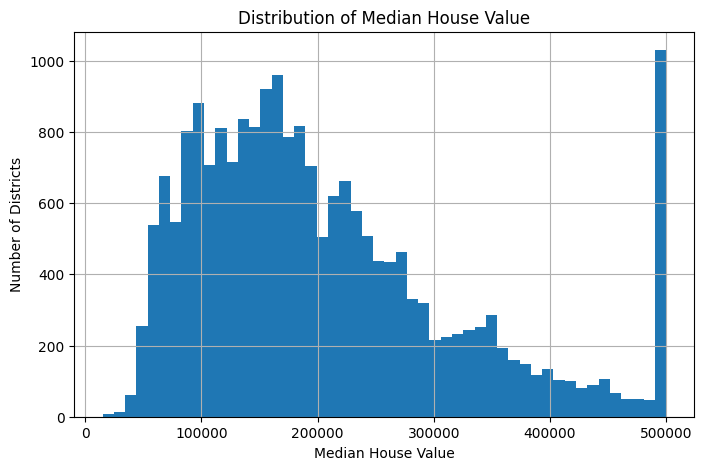

In [32]:
# Histogram of median house values
df["median_house_value"].hist(bins=50, figsize=(8, 5))
plt.xlabel("Median House Value")
plt.ylabel("Number of Districts")
plt.title("Distribution of Median House Value")
plt.show()

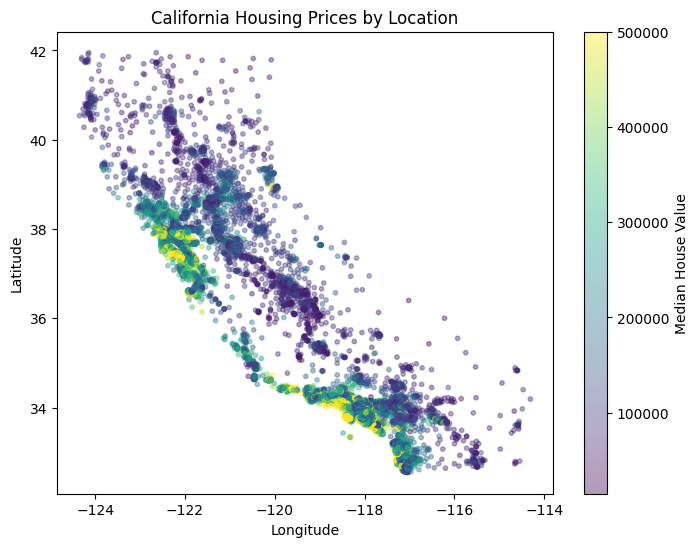

In [33]:
# Scatter plot of geographic location, colored by house value
plt.figure(figsize=(8, 6))
plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"], cmap="viridis", alpha=0.4, s=10)
plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Location")
plt.show()

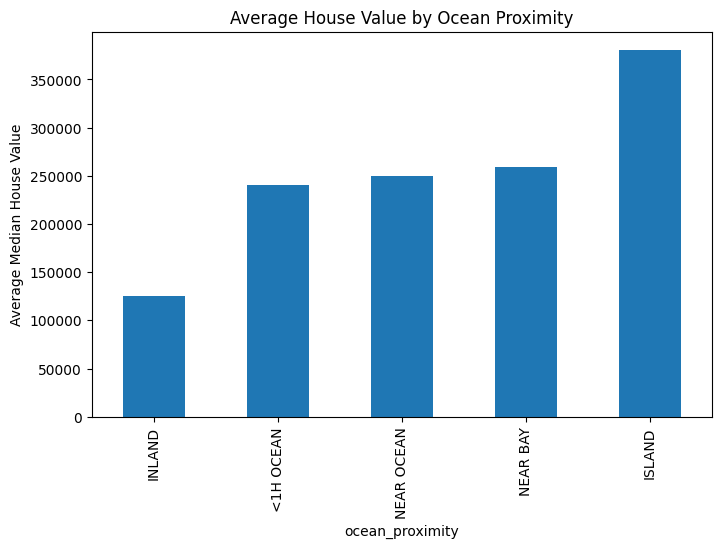

In [34]:
# Bar chart of average house value by ocean proximity
df.groupby("ocean_proximity")["median_house_value"].mean().sort_values().plot(kind="bar", figsize=(8, 5))
plt.ylabel("Average Median House Value")
plt.title("Average House Value by Ocean Proximity")
plt.show()

## 11. Saving the Dataset

In [35]:
# Save the (possibly modified) dataframe back to a CSV file
df.to_csv("housing_processed.csv", index=False)
print("Saved!")

Saved!


## 12. Exercises

Try these on your own to test your understanding:

1. Use `apply`/lambda to calculate the mean deviation of `median_income` and store it in a new column.
2. Do (1) again, but using vectorized Pandas operations instead of `.apply()` — compare the speed.
3. Create a new column `bedrooms_per_room` = `total_bedrooms` / `total_rooms`.
4. Create a pivot table showing average `population` per `ocean_proximity` category.
5. Drop all rows with missing values (or fill them with the column mean) and save the cleaned dataset with `to_csv()`.
6. Find the 5 districts with the highest `median_income` and inspect their `ocean_proximity`.

In [36]:
# Your code here
